In [3]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(12345) #pi seed for pi finding

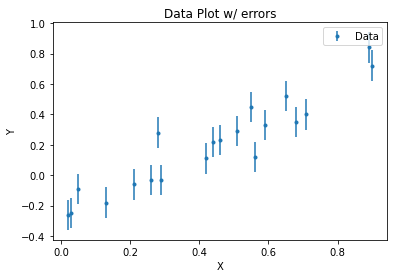

In [4]:
#This is my data input for the .txt files, may need to adjust the filepath
Data=pd.read_csv('HW6_Data/model_selection.txt', names=['x', 'y', 'yerr'], delim_whitespace=True)

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

Problem 1.)

22857.507994491156
[ 1.10204082 -0.28571429]


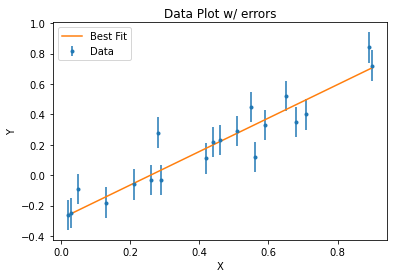

In [55]:
#Part A is calculating p(D|M_1) where M_1=y=mx+b and p(D|M_1) = integral over theta of p(D|theta)p(theta|M)dtheta
#And theta we can assume are uniform from -2 to 2 for both slope and yint
#Assume data errorvalues are Gaussian

#I need my parameters, which will just be a flattened 2D grid
density = 50
mlist = np.linspace(-2, 2, density)
blist = np.linspace(-2, 2, density)
M, B = np.meshgrid(mlist, blist) #makes the 2D grid
theta = np.column_stack((M.ravel(), B.ravel())) #flattens it out. Theta is now a list of [slope, yint]

#OK now we have our prior, we need to have a likelyhood function 
#Copying some code from HW4 and HW5
def logPDataGivenParam(Data, theta):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(-0.5 * (((Data['y'][i] - (theta[0]*Data['x'][i]+theta[1]))/Data['yerr'][i])**2 
                            + np.log(2*np.pi*Data['yerr'][i]**2)))
    logLikelyhood = np.sum(temp) 
    return(logLikelyhood)

#now we need to cover p(theta|M)
#Since we have uniform priors between -2 and 2 I think this is just a constant
#Should be like 1/(4)(4) where each 4 is the range of prior (-2 to 2)
Prior=1/16
da = (mlist[1] - mlist[0]) #gets spacing for integral
db = (blist[1] - blist[0])

#now we actually do the integral
#Except we can convert this to a sum since we have discrete points
temp_2parameters = 0
LikelyhoodValues = []
for theta_i in theta:
    Likelyhood = np.exp(logPDataGivenParam(Data, theta_i))
    temp_2parameters += Likelyhood * Prior * da * db
    LikelyhoodValues.append(Likelyhood)
print(temp_2parameters)
thetabest = theta[np.argmax(LikelyhoodValues)]
print(theta[np.argmax(LikelyhoodValues)])
#This is pretty reasonable values for theta looking at the data

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], Data['x']*thetabest[0] + thetabest[1], label='Best Fit')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

7454.627464432162
[ 0.7755102  -0.20408163  0.28571429]


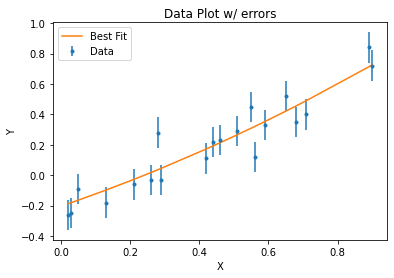

In [56]:
#Part B here we use a quadratic model with a new parameter in theta for cx^2
density = 50
mlist = np.linspace(-2, 2, density)
blist = np.linspace(-2, 2, density)
clist = np.linspace(-2, 2, density)
M, B, C = np.meshgrid(mlist, blist, clist) #makes the 2D grid
theta = np.column_stack((M.ravel(), B.ravel(), C.ravel())) #flattens it out. Theta is now a list of [slope, yint]

def logPDataGivenParam(Data, theta):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(-0.5 * (((Data['y'][i] - (theta[0]*Data['x'][i]+theta[1]+theta[2]*Data['x'][i]**2))/Data['yerr'][i])**2 
                            + np.log(2*np.pi*Data['yerr'][i]**2)))
    logLikelyhood = np.sum(temp) 
    return(logLikelyhood)

Prior=1/(4**3)
da = (mlist[1] - mlist[0]) #gets spacing for integral
db = (blist[1] - blist[0])
dc = (clist[1] - clist[0])

temp_3parameters = 0
LikelyhoodValues = []
for theta_i in theta:
    Likelyhood = np.exp(logPDataGivenParam(Data, theta_i))
    temp_3parameters += Likelyhood * Prior * da * db * dc
    LikelyhoodValues.append(Likelyhood)
print(temp_3parameters)
thetabest = theta[np.argmax(LikelyhoodValues)]
print(theta[np.argmax(LikelyhoodValues)])

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], Data['x']*thetabest[0] + thetabest[1] + Data['x']**2 * thetabest[2], label='Best Fit')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

In [57]:
#now for B_ij
#B_ij = p(M_i|D)/p(M_j|D) * p(M_j)/p(M_i)
#Since the priors are uniform, we can ignore that part. No prior saying we should take one model over the other more

#B_ij = p(M_i|D)/p(M_j|D)
print('B_ij:', temp_2parameters/temp_3parameters)
#This is the Bayes factor for linear/quadratic. So we are in favor of a linear model being the better model
#I don't think it's the strongest support for, but the Bayes factor shows that the slight improvement in fit
#given by the quadratic model is not worth the added complexity from the quadratic model

B_ij: 3.066217339974382


Problem 2

Optimized Parameters: m= 1.0684219729206805
Optimized Parameters: b= -0.26302408367276386


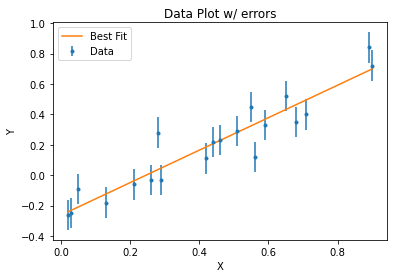

p value: 0.28525274714583976
reduced chi2: 1.160279793007025


In [34]:
#part a
#compute a chi2 for a linear fit, optimize, and report the best slope and yint values
def Chi2(Data, m, b):
    Chi2=np.sum((Data['y'] - (m*Data['x']+b))**2 / Data['yerr']**2)
    return(Chi2)

def Chi2Minimizer(theta, Data):
    m, b = theta
    return Chi2(Data, m, b)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[1, -0.1], args=(Data,))
m, b = scipy.optimize.minimize(Chi2Minimizer, x0=[1, -0.1], args=(Data,)).x
chi2optLinear = chi2minimized.fun
print('Optimized Parameters: m=', m)
print('Optimized Parameters: b=', b)

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], Data['x']*m + b, label='Best Fit')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

#Let's do pvalue stuff
#It's basically the integral of the chi2 function from our chi2 value to infinity
#scipy.stats.sf is the survival function which does exactly that

pvalue = scipy.stats.chi2.sf(chi2optLinear, len(Data)-2)
print('p value:', pvalue)
print('reduced chi2:', chi2optLinear/(len(Data)-2))

Optimized Parameters: m= 0.7921778261208063
Optimized Parameters: b= -0.22427637748987922
Optimized Parameters: c= 0.3159984998131077


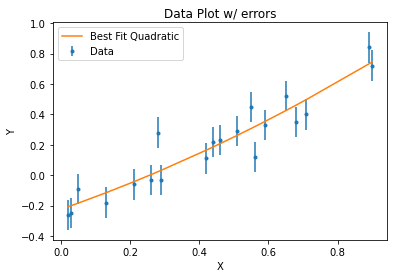

p value: 0.23147493837364042
reduced chi2: 1.22853154553685


In [35]:
#part b
#compute a chi2 for a quadratic fit, optimize, and report the best parameters
def Chi2(Data, m, b, c):
    Chi2=np.sum((Data['y'] - (c*Data['x']**2 + m*Data['x']+b))**2 / Data['yerr']**2)
    return(Chi2)

def Chi2Minimizer(theta, Data):
    m, b, c = theta
    return Chi2(Data, m, b, c)

chi2minimized=scipy.optimize.minimize(Chi2Minimizer, x0=[1, -0.1, .2], args=(Data,))
m, b, c = chi2minimized.x
chi2optQuadratic = chi2minimized.fun
print('Optimized Parameters: m=', m)
print('Optimized Parameters: b=', b)
print('Optimized Parameters: c=', c)

plt.errorbar(Data['x'], Data['y'], yerr=Data['yerr'], label='Data', linestyle='', fmt='.')
plt.plot(Data['x'], c*Data['x']**2 + Data['x']*m + b, label='Best Fit Quadratic')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

pvalue = scipy.stats.chi2.sf(chi2optLinear, len(Data)-3)
print('p value:', pvalue)
print('reduced chi2:', chi2optLinear/(len(Data)-3))

In [37]:
#part 3
deltachi2 = chi2optLinear - chi2optQuadratic
pvalue = scipy.stats.chi2.sf(deltachi2, 1)
print('p value:', pvalue)

#This result is saying the difference in chi2 values being what it is has a 31.7% chance of just being random fluctuation
#Given this, we can say the linear model is prefered, since it is very likely random fluctuations give us the quadratic improvement
#Therefore we can use the simpler model without losing fidelity

#p values aren't an end-all-be-all number because of the dataset, things like phacking but also
#things like the unintuitive nature of pvalues and the size of the data sample make it more of a challenge to interpret

p value: 0.31724203358731656
